In [74]:
import json
import pandas as pd
import os
import numpy as np

def process_cricket_data_complete(directory_path):
    all_match_records = []
    
    # 1. PARSE JSONS
    for filename in os.listdir(directory_path):
        if filename.endswith('.json'):
            file_path = os.path.join(directory_path, filename)
            
            with open(file_path, 'r') as f:
                try:
                    data = json.load(f)
                    
                    info = data.get('info', {})
                    match_id = filename.split('.')[0]
                    venue = info.get('venue', 'Unknown')
                    city = info.get('city', 'Unknown')
                    date = info.get('dates', [None])[0]
                    teams = info.get('teams', [])
                    winner = info.get('outcome', {}).get('winner', 'No Result')
                    toss_winner = info.get('toss', {}).get('winner')
                    toss_decision = info.get('toss', {}).get('decision')
                    
                    # Innings Loop
                    for inning_num, inning in enumerate(data.get('innings', [])):
                        team_name = inning.get('team')
                        
                        # Identify bowling team
                        bowling_team = next((t for t in teams if t != team_name), 'Unknown')
                        
                        for over_data in inning.get('overs', []):
                            over_num = over_data.get('over')
                            
                            for ball_num, delivery in enumerate(over_data.get('deliveries', [])):
                                # Run Splits
                                runs = delivery.get('runs', {})
                                runs_batter = runs.get('batter', 0)
                                runs_extras = runs.get('extras', 0)
                                runs_total = runs.get('total', 0)
                                
                                # Extra Type & Legal Ball Check
                                extras = delivery.get('extras', {})
                                is_wide = 'wides' in extras
                                is_noball = 'noballs' in extras
                                # 1 if wide/noball, 0 if legal
                                is_extra_ball = 1 if (is_wide or is_noball) else 0
                                
                                # Wicket Check
                                is_wicket = 1 if 'wickets' in delivery else 0
                                
                                record = {
                                    'match_id': match_id,
                                    'city': city,
                                    'venue': venue,
                                    'date': date,
                                    'winner': winner,
                                    'toss_winner': toss_winner,
                                    'toss_decision': toss_decision,
                                    'inning': inning_num + 1,
                                    'batting_team': team_name,
                                    'bowling_team': bowling_team,
                                    'over': over_num,
                                    'ball': ball_num + 1,
                                    'batter': delivery.get('batter'),
                                    'bowler': delivery.get('bowler'),
                                    'runs_batter': runs_batter,
                                    'runs_extras': runs_extras,
                                    'runs_total': runs_total,
                                    'is_wicket': is_wicket,
                                    'is_extra_ball': is_extra_ball
                                }
                                all_match_records.append(record)

                except Exception as e:
                    print(f"Error processing {filename}: {e}")

    df = pd.DataFrame(all_match_records)
    
    # 2. FEATURE ENGINEERING (The Calculations)
    print("Calculating detailed match statistics...")
    
    # Sort to ensure sequential calculation
    df = df.sort_values(['match_id', 'inning', 'over', 'ball'])
    
    # A. Current Score (Cumulative)
    df['current_score'] = df.groupby(['match_id', 'inning'])['runs_total'].cumsum()
    
    # B. Legal Balls & Balls Left
    df['is_legal'] = 1 - df['is_extra_ball']
    df['legal_balls_bowled'] = df.groupby(['match_id', 'inning'])['is_legal'].cumsum()
    df['balls_left'] = 120 - df['legal_balls_bowled']
    df['balls_left'] = df['balls_left'].clip(lower=0)
    
    # C. Wickets Left
    df['wickets_lost'] = df.groupby(['match_id', 'inning'])['is_wicket'].cumsum()
    df['wickets_left'] = 10 - df['wickets_lost']
    df['wickets_left'] = df['wickets_left'].clip(lower=0)
    
    # D. Target Score & Runs Needed
    # Calculate total runs scored in inning 1 for every match
    inning1_totals = df[df['inning'] == 1].groupby('match_id')['current_score'].max().reset_index()
    inning1_totals.columns = ['match_id', 'inning1_total']
    
    # Merge back to main df
    df = pd.merge(df, inning1_totals, on='match_id', how='left')
    
    # Target is Inning 1 Total + 1
    df['target_score'] = df['inning1_total'] + 1
    
    # Calculate Runs Needed (Target - Current Score)
    df['runs_needed'] = df['target_score'] - df['current_score']
    
    # CLEANUP: Runs needed only makes sense for Inning 2
    # For Inning 1, we can set it to 0 or NaN
    df.loc[df['inning'] == 1, 'runs_needed'] = 0
    df.loc[df['inning'] == 1, 'target_score'] = 0
    
    # E. Result Label (1 if Batting Team Won, 0 if Lost)
    df['result'] = (df['batting_team'] == df['winner']).astype(int)

    return df


path = '/Users/sakshi/Downloads/icc_mens_t20_worldcup_project'


master_df = process_cricket_data_complete(path)

master_df.to_csv('master_cricket_data.csv', index=False)
print("'master_cricket_data.csv' created.")

Calculating detailed match statistics...
'master_cricket_data.csv' created.


In [75]:
import pandas as pd
df = pd.read_csv('master_cricket_data.csv')
print(f"Total rows (balls) loaded: {len(df)}")

Total rows (balls) loaded: 40966


In [76]:
unique_locations = master_df[['city', 'venue']].drop_duplicates()
print(unique_locations)

              city                                              venue
0        Al Amarat  Al Amerat Cricket Ground Oman Cricket (Ministr...
457      Abu Dhabi                   Zayed Cricket Stadium, Abu Dhabi
2335       Sharjah                            Sharjah Cricket Stadium
2922         Dubai                Dubai International Cricket Stadium
9023       Geelong             GMHBA Stadium, South Geelong, Victoria
9510        Hobart                             Bellerive Oval, Hobart
11929       Sydney                              Sydney Cricket Ground
12373    Melbourne                           Melbourne Cricket Ground
12953        Perth                                      Perth Stadium
14379     Brisbane   Brisbane Cricket Ground, Woolloongabba, Brisbane
15564     Adelaide                                      Adelaide Oval
18149       Dallas                      Grand Prairie Stadium, Dallas
18390   Providence                         Providence Stadium, Guyana
18631   Bridgetown  

In [77]:
import pandas as pd

#manual mapping since the free apis keep blocking id even after several tries
data = {
    'city': [
        'New York', 'Dallas', 'Lauderhill', 'Bridgetown', 'Gros Islet', 'North Sound', 
        'Melbourne', 'Sydney', 'Adelaide', 'Dubai', 'Abu Dhabi', 'Muscat', 
        'Dhaka', 'Chittagong', 'Sylhet', 'Kolkata', 'Mumbai', 'Bangalore', 
        'Nagpur', 'Mohali', 'Dharamsala', 'Providence', 'Kingstown', 'Tarouba',
        'Geelong', 'Hobart', 'Perth', 'Brisbane', 'Delhi', 'Lucknow', 'St Lucia'
    ],
    'venue': [
        'Nassau County International Cricket Stadium', 'Grand Prairie Stadium', 'Central Broward Park', 
        'Kensington Oval', 'Daren Sammy National Cricket Stadium', 'Sir Vivian Richards Stadium',
        'Melbourne Cricket Ground', 'Sydney Cricket Ground', 'Adelaide Oval', 
        'Dubai International Cricket Stadium', 'Sheikh Zayed Stadium', 'Oman Cricket Academy Ground',
        'Sher-e-Bangla National Cricket Stadium', 'Zahur Ahmed Chowdhury Stadium', 'Sylhet International Cricket Stadium',
        'Eden Gardens', 'Wankhede Stadium', 'M.Chinnaswamy Stadium',
        'Vidarbha Cricket Association Stadium', 'Punjab Cricket Association IS Bindra Stadium', 'Himachal Pradesh Cricket Association Stadium',
        'Providence Stadium', 'Arnos Vale Ground', 'Brian Lara Stadium',
        'Kardinia Park', 'Bellerive Oval', 'Perth Stadium', 'The Gabba', 
        'Arun Jaitley Stadium', 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium', 'Beausejour Stadium'
    ],
    'latitude': [
        40.7247, 32.7758, 26.1408, 13.1065, 14.0754, 17.1197, 
        -37.8200, -33.8915, -34.9155, 25.0480, 24.3989, 23.4770, 
        23.8069, 22.3582, 24.9161, 22.5646, 18.9389, 12.9788,
        21.1091, 30.6909, 32.1976, 6.7570, 13.1411, 10.3200,
        -38.1585, -42.8770, -31.9511, -27.4858, 28.6377, 26.8117, 14.0741
    ],
    'longitude': [
        -73.5855, -96.9536, -80.2039, -59.6247, -60.9414, -61.7825, 
        144.9834, 151.2248, 138.5961, 55.2217, 54.5428, 58.5300, 
        90.3649, 91.7656, 91.8700, 88.3433, 72.8258, 77.5996,
        79.0225, 76.7373, 76.3258, -58.1725, -61.2128, -61.4172,
        144.3501, 147.3736, 115.8891, 153.0381, 77.2431, 81.0441, -60.9414
    ]
}

venue_coords_df = pd.DataFrame(data)

venue_coords_df.to_csv('venue_coordinates.csv', index=False)
print(" Full coordinates file 'venue_coordinates.csv' created.")
print(f"Total venues now mapped: {len(venue_coords_df)}")

 Full coordinates file 'venue_coordinates.csv' created.
Total venues now mapped: 31


In [78]:
# merge 
master_df = pd.read_csv('master_cricket_data.csv')
master_df_final = pd.merge(master_df, venue_coords_df, on=['city', 'venue'], how='left')

# checking for any missing values
missing_count = master_df_final['latitude'].isna().sum()
if missing_count == 0:
    print("Every ball in your dataset now has geographic coordinates")
else:
    print(f"Warning: {missing_count} rows still missing coordinates.")

master_df_final.to_csv('master_cricket_data_with_coords.csv', index=False)

In [79]:
missing_data = master_df_final[master_df_final['latitude'].isna()]


failed_names = missing_data[['city', 'venue']].drop_duplicates()
print("These specific names in your data found no match in our list:")
print(failed_names)

These specific names in your data found no match in our list:
              city                                              venue
0        Al Amarat  Al Amerat Cricket Ground Oman Cricket (Ministr...
457      Abu Dhabi                   Zayed Cricket Stadium, Abu Dhabi
2335       Sharjah                            Sharjah Cricket Stadium
9023       Geelong             GMHBA Stadium, South Geelong, Victoria
9510        Hobart                             Bellerive Oval, Hobart
14379     Brisbane   Brisbane Cricket Ground, Woolloongabba, Brisbane
18149       Dallas                      Grand Prairie Stadium, Dallas
18390   Providence                         Providence Stadium, Guyana
18631   Bridgetown              Kensington Oval, Bridgetown, Barbados
18886     New York  Nassau County International Cricket Stadium, N...
22019  North Sound  Sir Vivian Richards Stadium, North Sound, Antigua
23083      Tarouba              Brian Lara Stadium, Tarouba, Trinidad
23329    Kingstown          

In [80]:
import pandas as pd

# Create the mapping based EXACTLY on  "failed_names" list
mapping_data = {
    'venue': [
        'Shere Bangla National Stadium', 'Sharjah Cricket Stadium', 'Bellerive Oval, Hobart',
        'Zayed Cricket Stadium, Abu Dhabi', 'Sir Vivian Richards Stadium, North Sound, Antigua',
        'Nassau County International Cricket Stadium, New York', 
        'Central Broward Regional Park Stadium Turf Ground',
        'Vidarbha Cricket Association Stadium, Jamtha', 
        'GMHBA Stadium, South Geelong, Victoria', 'Sylhet Stadium',
        'Punjab Cricket Association IS Bindra Stadium, Mohali',
        'Arnos Vale Ground, Kingstown, St Vincent', 'Kensington Oval, Bridgetown, Barbados',
        'Grand Prairie Stadium, Dallas', 'Brian Lara Stadium, Tarouba, Trinidad',
        'Brisbane Cricket Ground, Woolloongabba, Brisbane',
        'Al Amerat Cricket Ground Oman Cricket (Ministry Turf 1)',
        'Daren Sammy National Cricket Stadium, Gros Islet, St Lucia',
        'M Chinnaswamy Stadium', 'Feroz Shah Kotla', 'Zahur Ahmed Chowdhury Stadium',
        'Providence Stadium, Guyana'
    ],
    'lat': [
        23.8069, 25.3300, -42.8770, 24.3989, 17.1197, 40.7247, 26.1408, 21.1091, 
        -38.1585, 24.9161, 30.6909, 13.1411, 13.1065, 32.7758, 10.3200, -27.4858, 
        23.4770, 14.0754, 12.9788, 28.6377, 22.3582, 6.7570
    ],
    'lon': [
        90.3649, 55.4200, 147.3736, 54.5428, -61.7825, -73.5855, -80.2039, 79.0225, 
        144.3501, 91.8700, 76.7373, -61.2128, -59.6247, -96.9536, -61.4172, 153.0381, 
        58.5300, -60.9414, 77.5996, 77.2431, 91.7656, -58.1725
    ]
}

coords_df = pd.DataFrame(mapping_data)

#  Merging this with your master_df using ONLY the 'venue' column 
# (This is safer since the venue names already contain the city info)
master_df_final = pd.merge(master_df, coords_df, on='venue', how='left')

missing_final = master_df_final['lat'].isna().sum()
print(f"Success! Remaining missing rows: {missing_final}")

if missing_final == 0:
    print("Every single ball now has a location!")
    master_df_final.to_csv('master_cricket_data_with_coords.csv', index=False)

Success! Remaining missing rows: 10403


In [81]:
still_missing = master_df_final[master_df_final['lat'].isna()]
print("Still missing these venues:")
print(still_missing[['city', 'venue']].drop_duplicates())

Still missing these venues:
             city                                              venue
2922        Dubai                Dubai International Cricket Stadium
11929      Sydney                              Sydney Cricket Ground
12373   Melbourne                           Melbourne Cricket Ground
12953       Perth                                      Perth Stadium
15564    Adelaide                                      Adelaide Oval
24453  Lauderhill  Central Broward Regional Park Stadium Turf Gro...
35175  Dharamsala       Himachal Pradesh Cricket Association Stadium
36647      Mumbai                                   Wankhede Stadium
36894     Kolkata                                       Eden Gardens


In [ ]:
import pandas as pd

# This dictionary now matches the EXACT names from failed_names list
mapping_data = {
    'venue': [
        'Sydney Cricket Ground', 'Wankhede Stadium', 
        'Central Broward Regional Park Stadium Turf Ground',
        'Dubai International Cricket Stadium', 'Himachal Pradesh Cricket Association Stadium',
        'Melbourne Cricket Ground', 'Eden Gardens', 'Adelaide Oval', 'Perth Stadium',
        'Shere Bangla National Stadium', 'Sharjah Cricket Stadium', 'Bellerive Oval, Hobart',
        'Zayed Cricket Stadium, Abu Dhabi', 'Sir Vivian Richards Stadium, North Sound, Antigua',
        'Nassau County International Cricket Stadium, New York', 
        'Vidarbha Cricket Association Stadium, Jamtha', 
        'GMHBA Stadium, South Geelong, Victoria', 'Sylhet Stadium',
        'Punjab Cricket Association IS Bindra Stadium, Mohali',
        'Arnos Vale Ground, Kingstown, St Vincent', 'Kensington Oval, Bridgetown, Barbados',
        'Grand Prairie Stadium, Dallas', 'Brian Lara Stadium, Tarouba, Trinidad',
        'Brisbane Cricket Ground, Woolloongabba, Brisbane',
        'Al Amerat Cricket Ground Oman Cricket (Ministry Turf 1)',
        'Daren Sammy National Cricket Stadium, Gros Islet, St Lucia',
        'M Chinnaswamy Stadium', 'Feroz Shah Kotla', 'Zahur Ahmed Chowdhury Stadium',
        'Providence Stadium, Guyana'
    ],
    'lat': [
        -33.8915, 18.9389, 26.1408, 25.0480, 32.1976, -37.8200, 22.5646, -34.9155, -31.9511,
        23.8069, 25.3300, -42.8770, 24.3989, 17.1197, 40.7247, 21.1091, -38.1585, 24.9161, 
        30.6909, 13.1411, 13.1065, 32.7758, 10.3200, -27.4858, 23.4770, 14.0754, 
        12.9788, 28.6377, 22.3582, 6.7570
    ],
    'lon': [
        151.2248, 72.8258, -80.2039, 55.2217, 76.3258, 144.9834, 88.3433, 138.5961, 115.8891,
        90.3649, 55.4200, 147.3736, 54.5428, -61.7825, -73.5855, 79.0225, 144.3501, 91.8700, 
        76.7373, -61.2128, -59.6247, -96.9536, -61.4172, 153.0381, 58.5300, -60.9414, 
        77.5996, 77.2431, 91.7656, -58.1725
    ]
}

coords_df = pd.DataFrame(mapping_data)


master_df_final = pd.merge(master_df, coords_df, on='venue', how='left')


missing_final = master_df_final['lat'].isna().sum()
print(f" Remaining missing rows: {missing_final}")

if missing_final == 0:
    print("Every ball now has coordinates.")
    master_df_final.to_csv('master_cricket_data_with_coords.csv', index=False)
else:
  
    print("Still missing:")
    print(master_df_final[master_df_final['lat'].isna()]['venue'].unique())

 Remaining missing rows: 239
Still missing:
['Central Broward Regional Park Stadium Turf Ground, Lauderhill']


In [ ]:
import pandas as pd

#  final missing Lauderhill variation
mapping_data = {
    'venue': [
        'Central Broward Regional Park Stadium Turf Ground, Lauderhill',
        'Sydney Cricket Ground', 'Wankhede Stadium', 
        'Central Broward Regional Park Stadium Turf Ground',
        'Dubai International Cricket Stadium', 'Himachal Pradesh Cricket Association Stadium',
        'Melbourne Cricket Ground', 'Eden Gardens', 'Adelaide Oval', 'Perth Stadium',
        'Shere Bangla National Stadium', 'Sharjah Cricket Stadium', 'Bellerive Oval, Hobart',
        'Zayed Cricket Stadium, Abu Dhabi', 'Sir Vivian Richards Stadium, North Sound, Antigua',
        'Nassau County International Cricket Stadium, New York', 
        'Vidarbha Cricket Association Stadium, Jamtha', 
        'GMHBA Stadium, South Geelong, Victoria', 'Sylhet Stadium',
        'Punjab Cricket Association IS Bindra Stadium, Mohali',
        'Arnos Vale Ground, Kingstown, St Vincent', 'Kensington Oval, Bridgetown, Barbados',
        'Grand Prairie Stadium, Dallas', 'Brian Lara Stadium, Tarouba, Trinidad',
        'Brisbane Cricket Ground, Woolloongabba, Brisbane',
        'Al Amerat Cricket Ground Oman Cricket (Ministry Turf 1)',
        'Daren Sammy National Cricket Stadium, Gros Islet, St Lucia',
        'M Chinnaswamy Stadium', 'Feroz Shah Kotla', 'Zahur Ahmed Chowdhury Stadium',
        'Providence Stadium, Guyana'
    ],
    'lat': [
        26.1408, -33.8915, 18.9389, 26.1408, 25.0480, 32.1976, -37.8200, 22.5646, 
        -34.9155, -31.9511, 23.8069, 25.3300, -42.8770, 24.3989, 17.1197, 40.7247, 
        21.1091, -38.1585, 24.9161, 30.6909, 13.1411, 13.1065, 32.7758, 10.3200, 
        -27.4858, 23.4770, 14.0754, 12.9788, 28.6377, 22.3582, 6.7570
    ],
    'lon': [
        -80.2039, 151.2248, 72.8258, -80.2039, 55.2217, 76.3258, 144.9834, 88.3433, 
        138.5961, 115.8891, 90.3649, 55.4200, 147.3736, 54.5428, -61.7825, -73.5855, 
        79.0225, 144.3501, 91.8700, 76.7373, -61.2128, -59.6247, -96.9536, -61.4172, 
        153.0381, 58.5300, -60.9414, 77.5996, 77.2431, 91.7656, -58.1725
    ]
}

coords_df = pd.DataFrame(mapping_data)

master_df_final = pd.merge(master_df, coords_df, on='venue', how='left')

missing_final = master_df_final['lat'].isna().sum()
print(f" Remaining missing rows: {missing_final}")

if missing_final == 0:
    master_df_final.to_csv('matches_with_coords.csv', index=False)

 Remaining missing rows: 0


In [84]:
import sys
!{sys.executable} -m pip install meteostat

In [85]:
import meteostat
print(f"Meteostat version: {meteostat.__version__}")
print("Import successful!")

Meteostat version: 1.6.0
Import successful!


In [ ]:
import ssl
import pandas as pd
import numpy as np
from datetime import datetime
from meteostat import Point, Daily

#  SSL Fix (Vital for some networks)
try:
    ssl._create_default_https_context = ssl._create_unverified_context
except AttributeError:
    pass


def get_weather(row):
    # Check for missing coords
    if pd.isna(row.get('lat')) or pd.isna(row.get('lon')):
        return pd.Series([np.nan]*5)

    try:
        # Handle Date Format Safely
        match_date = pd.to_datetime(row['date'])
        
        # Increase Radius 
        location = Point(row['latitude'], row['longitude'])
        location.radius = 100000  #Increased to 100km 
        
        # Fetch Data (Daily)
        data = Daily(location, match_date, match_date)
        data = data.fetch()
        
        if data.empty:
            return pd.Series([np.nan]*5)
        
        # Extract Data
        stats = data.iloc[0]
        return pd.Series([
            stats.get('tavg'),  # Avg Temp
            stats.get('tmin'),  # Min Temp
            stats.get('tmax'),  # Max Temp
            stats.get('prcp'),  # Precipitation
            stats.get('wspd')   # Wind Speed
        ])
        
    except Exception as e:
        return pd.Series([np.nan]*5)

if not df.empty:
    #  Fetch Weather for Unique Matches 

    unique_matches = df[['match_id', 'date', 'latitude', 'longitude']].drop_duplicates(subset=['match_id']).copy()

    weather_cols = ['temp_avg', 'temp_min', 'temp_max', 'precipitation_mm', 'wind_speed']
    unique_matches[weather_cols] = unique_matches.apply(get_weather, axis=1)

    unique_matches['is_rain'] = (unique_matches['precipitation_mm'] > 0).astype(int)
    # Set NaN where data is missing so we don't assume "No Rain" falsely
    unique_matches.loc[unique_matches['precipitation_mm'].isna(), 'is_rain'] = np.nan

    df_final = pd.merge(df, unique_matches[['match_id', 'temp_avg', 'temp_min', 'temp_max', 'precipitation_mm', 'wind_speed', 'is_rain']], on='match_id', how='left')

    output_file = 'matches_weather.csv'
    df_final.to_csv(output_file, index=False)

    print(f" Data saved to {output_file}")
    
    filled_count = df_final['temp_avg'].notna().sum()
    total_count = len(df_final)
    print(f"Weather data found for {filled_count} / {total_count} rows.")

KeyError: "['latitude', 'longitude'] not in index"

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('matches_weather.csv')

#  Fill missing precipitation with 0 (Assume Dry)
# This solves the issue of "not having values" for Oman/Eden Gardens/etc.
df['precipitation_mm'] = df['precipitation_mm'].fillna(0.0)

#  Create the Binary "Is Rain" Flag
# 0 = No Rain, 1 = Rain
df['is_rain'] = (df['precipitation_mm'] > 0).astype(int)

# Fill missing Temperatures with the average
df['temp_avg'] = df['temp_avg'].fillna(df['temp_avg'].mean())
df['temp_min'] = df['temp_min'].fillna(df['temp_min'].mean())
df['temp_max'] = df['temp_max'].fillna(df['temp_max'].mean())
df['wind_speed'] = df['wind_speed'].fillna(df['wind_speed'].mean())

df.to_csv('matches_with_weather.csv', index=False)


print(df[['venue', 'date', 'precipitation_mm', 'is_rain']].head())

                                               venue        date  \
0  Al Amerat Cricket Ground Oman Cricket (Ministr...  2021-10-17   
1  Al Amerat Cricket Ground Oman Cricket (Ministr...  2021-10-17   
2  Al Amerat Cricket Ground Oman Cricket (Ministr...  2021-10-17   
3  Al Amerat Cricket Ground Oman Cricket (Ministr...  2021-10-17   
4  Al Amerat Cricket Ground Oman Cricket (Ministr...  2021-10-17   

   precipitation_mm  is_rain  
0               0.0        0  
1               0.0        0  
2               0.0        0  
3               0.0        0  
4               0.0        0  


In [3]:
import sys
!{sys.executable} -m pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 6.4 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 371.1 kB/s  0:00:57m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [6]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

  Using cached pillow-12.0.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 2.3 MB/s  0:00:03 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 613.5 kB/s  0:00:04 eta 0:00:01
Using cached pillow-12.0.0-cp311-cp311-macosx_11_0_arm64.whl (4.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


In [ ]:
import pandas as pd
import numpy as np

df_eda = pd.read_csv('matches_with_weather.csv')

#  CRR (Current Run Rate)
# Formula: (Runs * 6) / Legal Balls
#  'division by zero' for the first ball of the match
df_eda['legal_balls_bowled'] = df_eda.groupby(['match_id', 'inning'])['is_extra_ball'].apply(lambda x: (1-x).cumsum()).reset_index(level=[0,1], drop=True)
df_eda['crr'] = np.where(df_eda['legal_balls_bowled'] == 0, 0, (df_eda['current_score'] * 6) / df_eda['legal_balls_bowled'])

# 3. Calculate RRR (Required Run Rate) - Only for 2nd Inning
# Formula: (Runs Needed * 6) / Balls Left
mask_chase = df_eda['inning'] == 2
df_eda['runs_needed'] = df_eda.loc[mask_chase, 'target_score'] - df_eda.loc[mask_chase, 'current_score']

# infinite RRR (when balls_left is 0)
df_eda['rrr'] = np.nan
df_eda.loc[mask_chase, 'rrr'] = (df_eda.loc[mask_chase, 'runs_needed'] * 6) / df_eda.loc[mask_chase, 'balls_left']
df_eda.loc[df_eda['balls_left'] == 0, 'rrr'] = 36 # Cap at 36 for visual safety

print(df_eda[['batting_team', 'current_score', 'crr', 'rrr']].head())

       batting_team  current_score  crr  rrr
0  Papua New Guinea              0  0.0  NaN
1  Papua New Guinea              0  0.0  NaN
2  Papua New Guinea              0  0.0  NaN
3  Papua New Guinea              0  0.0  NaN
4  Papua New Guinea              0  0.0  NaN



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



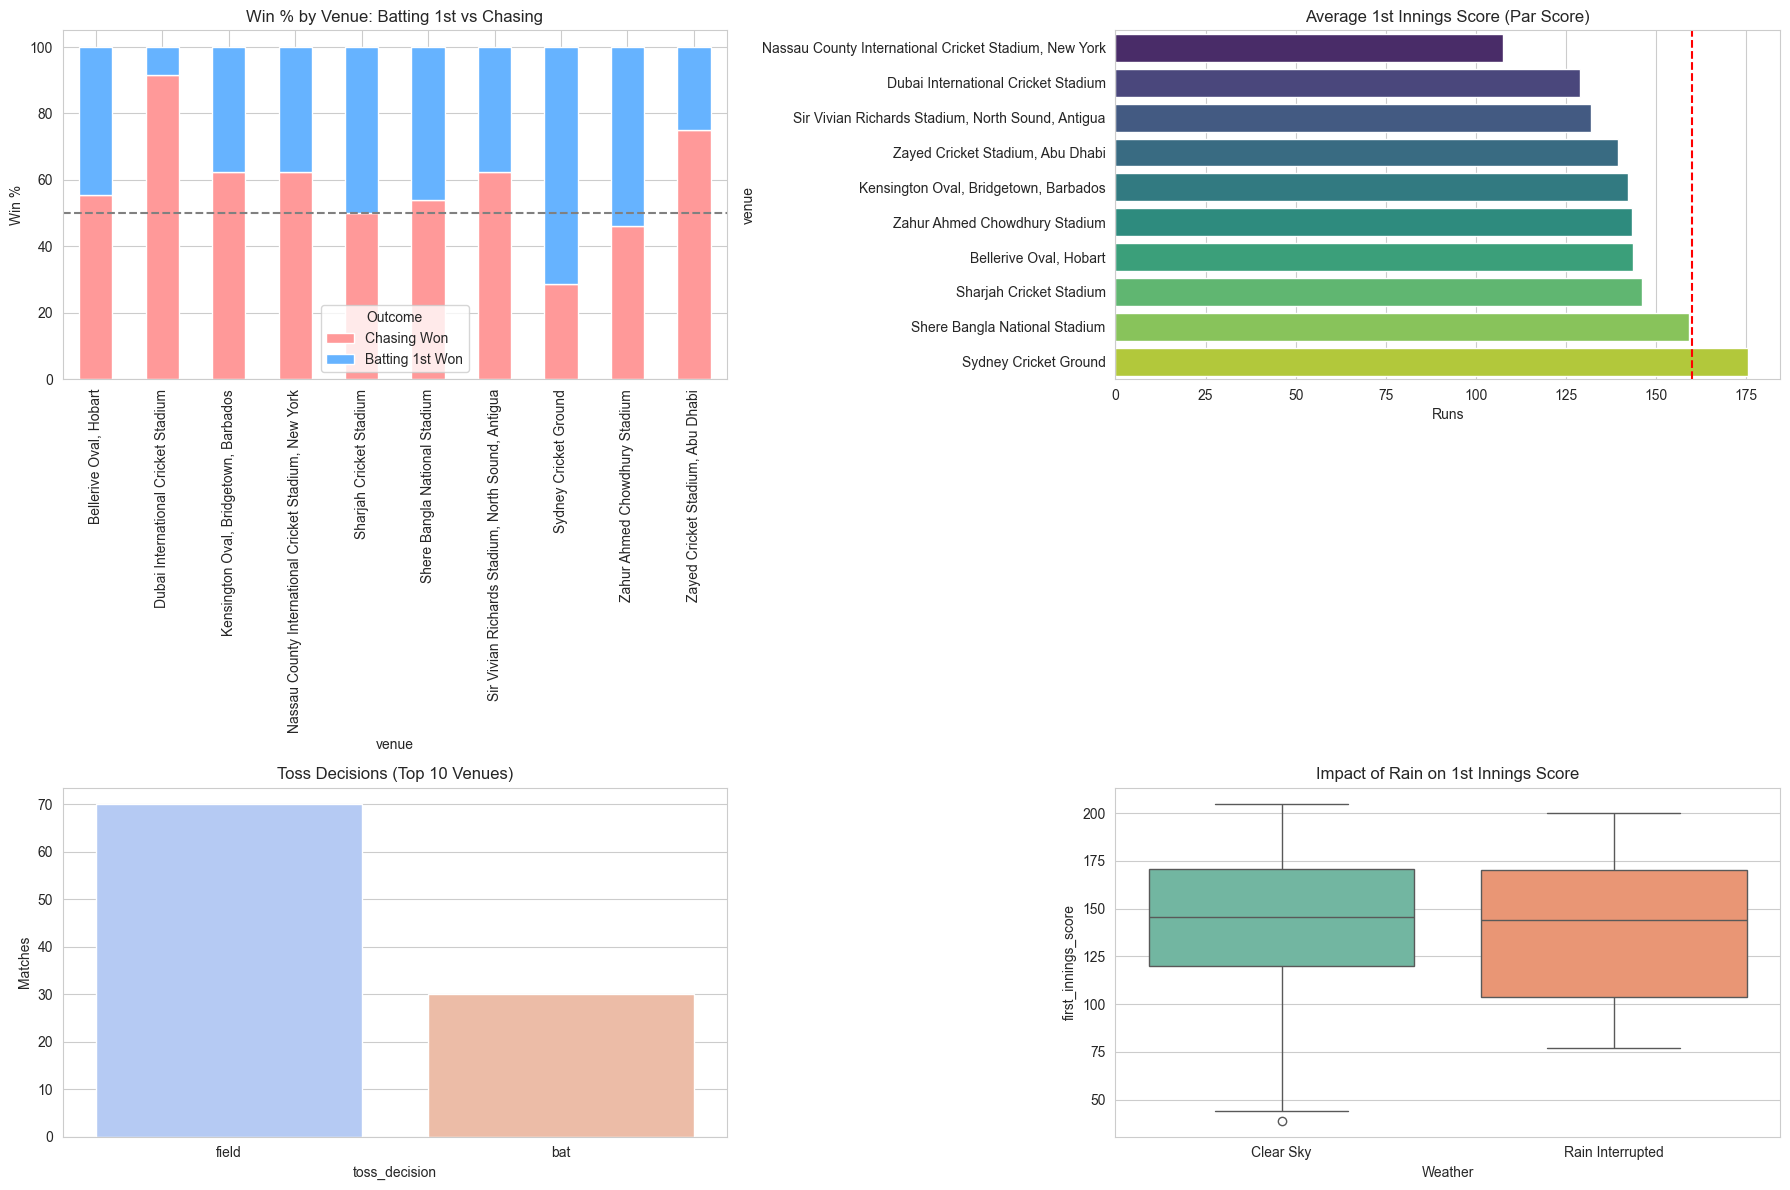

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#  Prepare Data: Filter for 1st Innings to analyze "Scores" and "Results"
# We focus on Top 10 venues to keep charts readable
top_venues_list = df_eda['venue'].value_counts().nlargest(10).index
df_top = df_eda[df_eda['venue'].isin(top_venues_list)]
first_innings = df_top[df_top['inning'] == 1]

# Create a dataset of 1 match per row with final scores
match_stats = first_innings.groupby(['match_id', 'venue', 'toss_decision', 'is_rain'])['current_score'].max().reset_index()
match_stats.rename(columns={'current_score': 'first_innings_score'}, inplace=True)

# Add Winner information to check Batting 1st vs Chasing wins
# We assume if the winner == batting_team of inning 1, then Batting 1st Won.
match_info = df_top[['match_id', 'winner', 'batting_team', 'inning']].drop_duplicates(subset='match_id')
match_stats = pd.merge(match_stats, match_info[['match_id', 'winner']], on='match_id')

# We need to re-attach the batting team name for Inning 1 to compare
inning1_teams = df_top[df_top['inning']==1].drop_duplicates(subset='match_id')[['match_id', 'batting_team']]
match_stats = pd.merge(match_stats, inning1_teams, on='match_id')
match_stats['bat_first_won'] = match_stats['winner'] == match_stats['batting_team']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4)

# CHART 1: Batting First vs. Chasing Wins by Venue
venue_win_rates = match_stats.groupby('venue')['bat_first_won'].value_counts(normalize=True).unstack().fillna(0) * 100
venue_win_rates.columns = ['Chasing Won', 'Batting 1st Won']
venue_win_rates.plot(kind='bar', stacked=True, ax=axes[0,0], color=['#ff9999', '#66b3ff'])
axes[0,0].set_title('Win % by Venue: Batting 1st vs Chasing')
axes[0,0].set_ylabel('Win %')
axes[0,0].axhline(50, color='gray', linestyle='--')
axes[0,0].legend(title='Outcome')

# CHART 2: Average 1st Innings Score by Venue
avg_scores = match_stats.groupby('venue')['first_innings_score'].mean().sort_values()
sns.barplot(x=avg_scores.values, y=avg_scores.index, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Average 1st Innings Score (Par Score)')
axes[0,1].set_xlabel('Runs')
axes[0,1].axvline(160, color='red', linestyle='--', label='160 Runs')

# CHART 3: Toss Decision Analysis
sns.countplot(data=match_stats, x='toss_decision', palette='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Toss Decisions (Top 10 Venues)')
axes[1,0].set_ylabel('Matches')

# CHART 4: Rain Impact on Scoring
# Map 0/1 to labels for better chart
match_stats['Weather'] = match_stats['is_rain'].map({0: 'Clear Sky', 1: 'Rain Interrupted'})
sns.boxplot(data=match_stats, x='Weather', y='first_innings_score', palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Impact of Rain on 1st Innings Score')
plt.tight_layout()
plt.show()

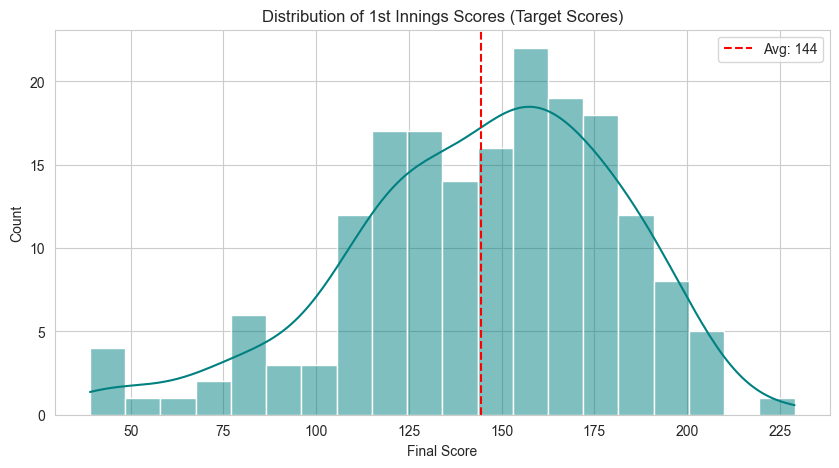

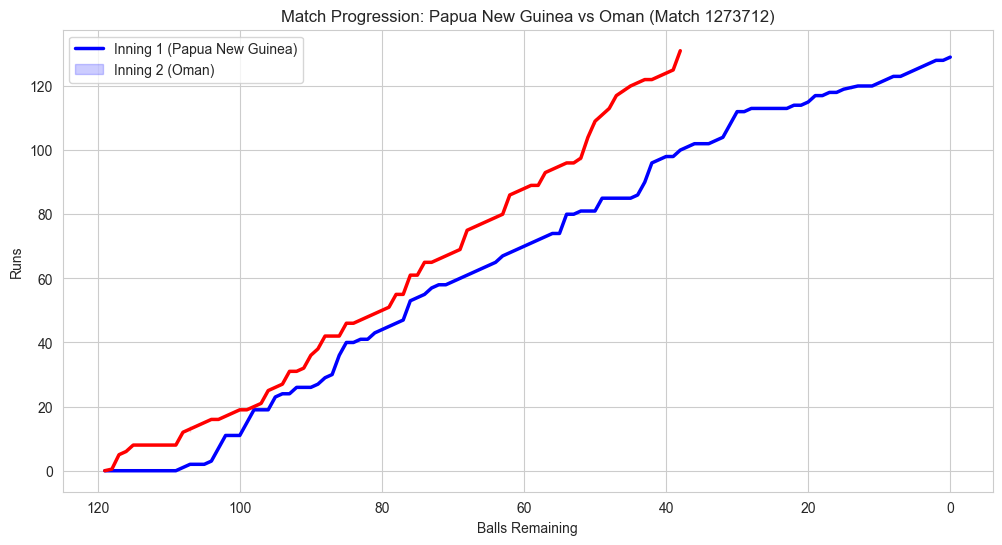

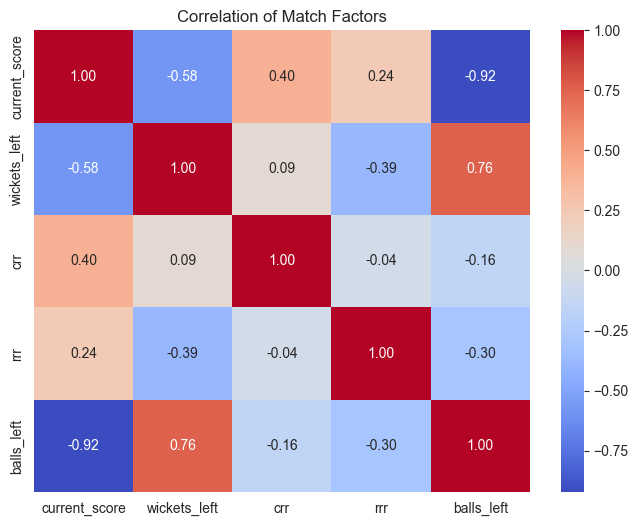

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use the same df_eda from before


#  CHART 5: Distribution of Scores (What is a "Good" Score?) 
plt.figure(figsize=(10, 5))
# Filter for 1st innings final scores
final_scores = df_eda[df_eda['inning'] == 1].groupby('match_id')['current_score'].max()
sns.histplot(final_scores, kde=True, bins=20, color='teal')
plt.title('Distribution of 1st Innings Scores (Target Scores)')
plt.xlabel('Final Score')
plt.axvline(final_scores.mean(), color='red', linestyle='--', label=f'Avg: {int(final_scores.mean())}')
plt.legend()
plt.show()

#  CHART 6: The Match Progression chart

sample_match = df_eda['match_id'].unique()[0] 
match_data = df_eda[df_eda['match_id'] == sample_match]
team1 = match_data[match_data['inning']==1]['batting_team'].iloc[0]
team2 = match_data[match_data['inning']==2]['batting_team'].iloc[0]

plt.figure(figsize=(12, 6))
sns.lineplot(data=match_data, x='balls_left', y='current_score', hue='inning', palette=['blue', 'red'], linewidth=2.5)
plt.gca().invert_xaxis() # Cricket goes from 120 balls to 0
plt.title(f'Match Progression: {team1} vs {team2} (Match {sample_match})')
plt.xlabel('Balls Remaining')
plt.ylabel('Runs')
plt.legend(labels=[f'Inning 1 ({team1})', f'Inning 2 ({team2})'])
plt.show()

#  CHART 7: Correlation Heatmap 
# Select numeric columns relevant to scoring
corr_cols = ['current_score', 'wickets_left', 'crr', 'rrr', 'balls_left']
# We drop NaN values to calculate correlation cleanly
corr_matrix = df_eda[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Match Factors')
plt.show()

In [41]:
import pandas as pd
import numpy as np

df = pd.read_csv('matches_with_weather.csv')

# current score
df['current_score'] = df.groupby(['match_id', 'inning'])['runs_total'].cumsum()

#final score
final_score_df = df.groupby(['match_id', 'inning'])['current_score'].max().reset_index()
final_score_df.rename(columns={'current_score': 'final_score'}, inplace=True)

df = pd.merge(df, final_score_df, on=['match_id', 'inning'])

df['legal_balls_bowled'] = (120 - df['balls_left'])

# CRR using 'current_score'
df['crr'] = np.where(df['legal_balls_bowled'] == 0, 0, (df['current_score'] * 6) / df['legal_balls_bowled'])

# RRR ( 2nd Inning)
df['runs_needed'] = df['target_score'] - df['current_score']
df['rrr'] = np.where(df['balls_left'] == 0, 36, (df['runs_needed'] * 6) / df['balls_left'])

df.loc[df['inning'] == 1, 'rrr'] = 0
df.loc[df['inning'] == 1, 'runs_needed'] = 0
df['rrr'] = df['rrr'].clip(lower=0, upper=36)

df['result_label'] = (df['winner'] == df['batting_team']).astype(int)


final_cols = [
    'match_id', 'inning', 
    'batting_team', 'bowling_team', 'venue', 
    'current_score',   # Input
    'final_score',     # Target
    'balls_left', 'wickets_left', 
    'crr', 'rrr', 'runs_needed', 'target_score', 
    'result_label', 'is_rain'
]

df_ready = df[final_cols].copy()
df_ready = df_ready[df_ready['balls_left'] > 0] # Remove last ball leakage

df_ready.to_csv('cricket_ml_ready.csv', index=False)

print(f"Columns: {list(df_ready.columns)}")
print(df_ready[['batting_team', 'current_score', 'final_score', 'balls_left']].head())

Columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'venue', 'current_score', 'final_score', 'balls_left', 'wickets_left', 'crr', 'rrr', 'runs_needed', 'target_score', 'result_label', 'is_rain']
       batting_team  current_score  final_score  balls_left
0  Papua New Guinea              0          129         119
1  Papua New Guinea              0          129         118
2  Papua New Guinea              0          129         117
3  Papua New Guinea              0          129         116
4  Papua New Guinea              0          129         115


In [26]:
import sys
!{sys.executable} -m pip install xgboost scikit-learn pandas numpy

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

df = pd.read_csv('cricket_ml_ready.csv')

# clean
df = df[df['balls_left'] > 0]
df = df[df['wickets_left'] > 0]

# prep data
df_win = df[df['inning'] == 2].copy()
df_win = df_win[df_win['runs_needed'] > 0]

# split
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
split = splitter.split(df_win, groups=df_win['match_id'])
train_inds, test_inds = next(split)

train_data = df_win.iloc[train_inds]
test_data = df_win.iloc[test_inds]

X_train = train_data[['batting_team', 'bowling_team', 'venue', 'runs_needed', 'balls_left', 
                      'wickets_left', 'target_score', 'crr', 'rrr', 'is_rain']]
y_train = train_data['result_label']

X_test = test_data[['batting_team', 'bowling_team', 'venue', 'runs_needed', 'balls_left', 
                    'wickets_left', 'target_score', 'crr', 'rrr', 'is_rain']]
y_test = test_data['result_label']

#  PIPELINE WITH RANDOM FOREST
trf_win = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), ['batting_team', 'bowling_team', 'venue']),
    ('num', StandardScaler(), ['runs_needed', 'balls_left', 'wickets_left', 'target_score', 'crr', 'rrr', 'is_rain'])
])

pipe = Pipeline([
    ('preprocessor', trf_win),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

#  TUNING (Crucial for small datasets)
# searching for the best "Depth" so it doesn't over-learn
params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_leaf': [1, 2, 4]
}

print(" Training Random Forest ")
clf = RandomizedSearchCV(pipe, params, cv=3, scoring='accuracy', n_iter=5, n_jobs=-1, random_state=42)
clf.fit(X_train, y_train)


best_model = clf.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f" Random Forest Accuracy: {acc:.2%}")
print(f"Best Params: {clf.best_params_}")



 Training Random Forest 


/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packa

 Random Forest Accuracy: 70.33%
Best Params: {'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 10}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle

df = pd.read_csv('cricket_ml_ready.csv')


# We use Inning 1 data to train the score predictor
df_score = df[df['inning'] == 1].copy()


splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
split = splitter.split(df_score, groups=df_score['match_id'])
train_inds, test_inds = next(split)

train_data = df_score.iloc[train_inds]
test_data = df_score.iloc[test_inds]

X_train = train_data[['batting_team', 'bowling_team', 'venue', 'current_score', 
                      'balls_left', 'wickets_left', 'crr', 'is_rain']]
y_train = train_data['final_score']

X_test = test_data[['batting_team', 'bowling_team', 'venue', 'current_score', 
                    'balls_left', 'wickets_left', 'crr', 'is_rain']]
y_test = test_data['final_score']

#  PIPELINE
trf_score = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=False, drop='first'), ['batting_team', 'bowling_team', 'venue']),
    ('num', StandardScaler(), ['current_score', 'balls_left', 'wickets_left', 'crr', 'is_rain'])
])

pipe = Pipeline([
    ('preprocessor', trf_score),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

#  TUNING
params = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5]
}

clf = RandomizedSearchCV(pipe, params, cv=3, scoring='neg_root_mean_squared_error', n_iter=5, n_jobs=-1, random_state=42)
clf.fit(X_train, y_train)

#  EVALUATE
best_model = clf.best_estimator_
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f" RMSE: {rmse:.2f} runs")
print(f" On average, the prediction is off by +/- {mae:.2f} runs")


/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packa

 RMSE: 27.59 runs
 On average, the prediction is off by +/- 20.68 runs


In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier  # couldnt load xgboost so alternative
from sklearn.metrics import accuracy_score
import pickle

df = pd.read_csv('cricket_ml_ready.csv')
df = df[(df['balls_left'] > 0) & (df['wickets_left'] > 0)]
df_win = df[(df['inning'] == 2) & (df['runs_needed'] > 0)].copy()

#  MATCH-SAFE SPLIT
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
split = splitter.split(df_win, groups=df_win['match_id'])
train_inds, test_inds = next(split)
train_data, test_data = df_win.iloc[train_inds], df_win.iloc[test_inds]

X_train = train_data[['batting_team', 'bowling_team', 'venue', 'runs_needed', 'balls_left', 
                      'wickets_left', 'target_score', 'crr', 'rrr', 'is_rain']]
y_train = train_data['result_label']
X_test = test_data[['batting_team', 'bowling_team', 'venue', 'runs_needed', 'balls_left', 
                    'wickets_left', 'target_score', 'crr', 'rrr', 'is_rain']]
y_test = test_data['result_label']

# PIPELINE
trf_win = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), ['batting_team', 'bowling_team', 'venue']),
    ('num', StandardScaler(), ['runs_needed', 'balls_left', 'wickets_left', 'target_score', 'crr', 'rrr', 'is_rain'])
])

pipe = Pipeline([
    ('preprocessor', trf_win),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

#  TUNING
params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5]
}

clf = RandomizedSearchCV(pipe, params, cv=3, scoring='accuracy', n_iter=5, n_jobs=-1, random_state=42)
clf.fit(X_train, y_train)

# EVALUATE
best_model = clf.best_estimator_
acc = accuracy_score(y_test, best_model.predict(X_test))
print(f" Gradient Boosting Accuracy: {acc:.2%}")


/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packa

 Gradient Boosting Accuracy: 63.46%


In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

#  Prepare Data (Score)
df_score = df[df['inning'] == 1].copy()
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
split = splitter.split(df_score, groups=df_score['match_id'])
train_inds, test_inds = next(split)
train_data, test_data = df_score.iloc[train_inds], df_score.iloc[test_inds]

X_train = train_data[['batting_team', 'bowling_team', 'venue', 'current_score', 
                      'balls_left', 'wickets_left', 'crr', 'is_rain']]
y_train = train_data['final_score']
X_test = test_data[['batting_team', 'bowling_team', 'venue', 'current_score', 
                    'balls_left', 'wickets_left', 'crr', 'is_rain']]
y_test = test_data['final_score']

#  PIPELINE
trf_score = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), ['batting_team', 'bowling_team', 'venue']),
    ('num', StandardScaler(), ['current_score', 'balls_left', 'wickets_left', 'crr', 'is_rain'])
])

pipe = Pipeline([
    ('preprocessor', trf_score),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# TUNING
params = {
    'regressor__n_estimators': [200, 300],         
    'regressor__learning_rate': [0.05, 0.1],        
    'regressor__max_depth': [4, 5]                 
}

print(" Training Gradient Boosting Score Predictor")
clf = RandomizedSearchCV(pipe, params, cv=3, scoring='neg_root_mean_squared_error', n_iter=5, n_jobs=-1, random_state=42)
clf.fit(X_train, y_train)

#  EVALUATE
best_model = clf.best_estimator_
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f" Gradient Boosting RMSE: {rmse:.2f} runs")


 Training Gradient Boosting Score Predictor


/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packa

 Gradient Boosting RMSE: 25.37 runs


In [49]:
import sys
!{sys.executable} -m pip install streamlit

In [60]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, mean_squared_error



df = pd.read_csv('cricket_ml_ready.csv')


# MODEL 1: SCORE PREDICTOR (The Pipeline Approach)

print("Gradient Boosting Pipeline")


df_score = df[df['inning'] == 1].copy()
X_score = df_score[['batting_team', 'bowling_team', 'venue', 'current_score', 
                    'balls_left', 'wickets_left', 'crr', 'is_rain']]
y_score = df_score['final_score']
groups_score = df_score['match_id']

# Split (Match-wise)
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_inds, test_inds = next(splitter.split(X_score, y_score, groups=groups_score))
X_train_s, X_test_s = X_score.iloc[train_inds], X_score.iloc[test_inds]
y_train_s, y_test_s = y_score.iloc[train_inds], y_score.iloc[test_inds]

# Define Pipeline
trf_score = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), 
     ['batting_team', 'bowling_team', 'venue']),
    ('num', StandardScaler(), 
     ['current_score', 'balls_left', 'wickets_left', 'crr', 'is_rain'])
])

pipe_score = Pipeline([
    ('preprocessor', trf_score),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# Tuning 
params = {
    'regressor__n_estimators': [200, 300],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [4, 5]
}

# Search & Train
search = RandomizedSearchCV(pipe_score, params, cv=3, scoring='neg_root_mean_squared_error', 
                            n_iter=5, n_jobs=-1, random_state=42)
search.fit(X_train_s, y_train_s)
best_score_model = search.best_estimator_

# Evaluate
y_pred_s = best_score_model.predict(X_test_s)
rmse = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
print(f" Gradient Boosting RMSE: {rmse:.2f} runs")


#  MODEL 2: WIN PREDICTOR (The Feature Engineering Approach)

print(" Training Win Predictor (Random Forest)")

# Prepare Data
df_win = df[df['inning'] == 2].copy()

#Label Encoding
le_batting = LabelEncoder()
le_bowling = LabelEncoder()
le_venue = LabelEncoder()

df['batting_team_encoded'] = le_batting.fit_transform(df['batting_team'])
df['bowling_team_encoded'] = le_bowling.fit_transform(df['bowling_team'])
df['venue_encoded'] = le_venue.fit_transform(df['venue'])

# Update df_win with encoded columns
df_win['batting_team_encoded'] = le_batting.transform(df_win['batting_team'])
df_win['bowling_team_encoded'] = le_bowling.transform(df_win['bowling_team'])
df_win['venue_encoded'] = le_venue.transform(df_win['venue'])

# Split (Match-wise)
groups_win = df_win['match_id']
train_inds_w, test_inds_w = next(splitter.split(df_win, groups=groups_win))
train_df_w = df_win.iloc[train_inds_w].copy()
test_df_w = df_win.iloc[test_inds_w].copy()

# Context Feature: Venue Bias (Calculated ONLY on Training Data)
venue_win_bias = train_df_w.groupby('venue')['result_label'].mean().to_dict()
global_win_bias = train_df_w['result_label'].mean()

def apply_bias(data):
    d = data.copy()
    d['venue_bias'] = d['venue'].map(venue_win_bias).fillna(global_win_bias)
    return d

train_df_w = apply_bias(train_df_w)
test_df_w = apply_bias(test_df_w)

# Features
features_win = ['batting_team_encoded', 'bowling_team_encoded', 'venue_encoded', 
                'runs_needed', 'balls_left', 'wickets_left', 'crr', 'rrr', 'venue_bias', 'is_rain']
X_train_w = train_df_w[features_win]
y_train_w = train_df_w['result_label']
X_test_w = test_df_w[features_win]
y_test_w = test_df_w['result_label']

# Train
win_model = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42)
win_model.fit(X_train_w, y_train_w)

# Evaluate
y_pred_w = win_model.predict(X_test_w)
acc = accuracy_score(y_test_w, y_pred_w)
print(f"Random Forest Accuracy: {acc*100:.2f}%")



Gradient Boosting Pipeline


/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sakshi/Downloads/icc_mens_t20_worldcup_project/cricket_env_64/lib/python3.11/site-packa

 Gradient Boosting RMSE: 25.37 runs
 Training Win Predictor (Random Forest)
Random Forest Accuracy: 73.44%


In [ ]:

final_bundle = {
    # 1. The Score Model (Gradient Boosting Pipeline)
    'score_model_pipeline': best_score_model, 
    
    # 2. The Win Model (Random Forest)
    'win_model': win_model,
    
    # 3. Encoders (Needed only for the Win Model)
    'win_encoders': {
        'batting_team': le_batting,
        'bowling_team': le_bowling,
        'venue': le_venue
    },
    
    # 4. Context Data (Venue Bias needed for the Win Model)
    'win_context': {
        'venue_bias': venue_win_bias,
        'global_bias': global_win_bias
    }
}

with open('cricket_models.pkl', 'wb') as f:
    pickle.dump(final_bundle, f)

print("Done")

Success
